# Polarizing Beam Splitter

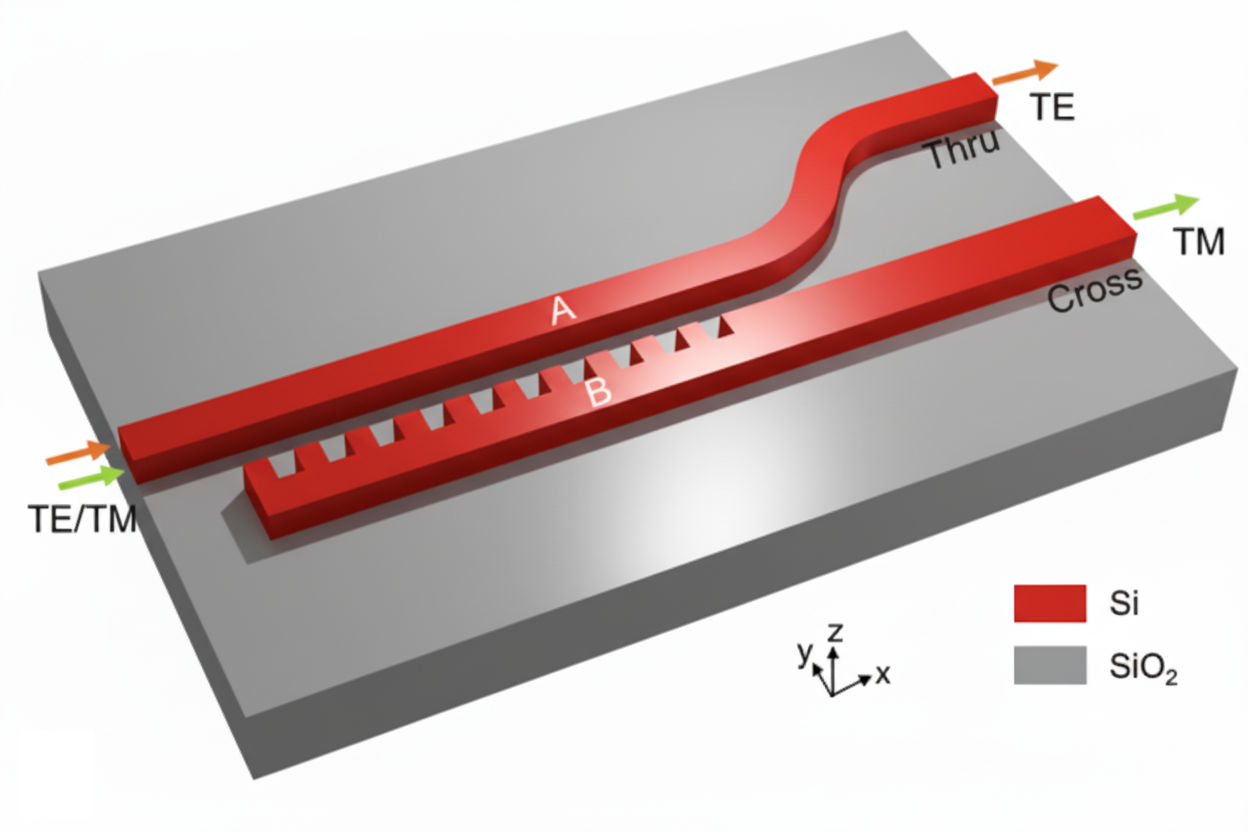

In this notebook, we reproduce the main simulation and design results presented in [1].  

The paper introduces a **polarizing beam splitter (PBS)** implemented on a **silicon-on-insulator (SOI)** platform. The device is based on an **asymmetric directional coupler (ADC)** composed of a conventional strip waveguide and a **subwavelength grating (SWG)** waveguide. By engineering the SWG geometry, the design achieves phase matching for TM polarization while maintaining a compact footprint and broadband operation.

In this notebook, we follow a systematic workflow to reproduce and analyze the results of the SWG-assisted PBS:

1. **Technology setup:** define the SOI platform, wavelength range, and mesh parameters.  
2. **Port definition and mode analysis:** construct and visualize the optical modes for both strip and SWG waveguides to ensure proper confinement and polarization behavior.  
3. **Component construction:** build the asymmetric directional coupler geometry with user-defined SWG parameters (period, duty cycle, and gap).  
4. **Frequency-domain simulation:** compute the scattering matrix ($S$-parameters) to extract transmission spectra for TE and TM inputs.  
5. **Field visualization:** plot the electric and magnetic field distributions to confirm polarization-selective coupling.

This structured approach reproduces the key experimental and simulated trends reported in the paper while maintaining flexibility for parameter exploration and design optimization.

**References**

1. Zhang, Fang, et al. "Ultra-broadband and compact polarizing beam splitter in silicon photonics." *OSA Continuum* 2020 3 (3), 560-567, doi: [10.1364/OSAC.385546](https://doi.org/10.1364/OSAC.385546).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import photonforge as pf
import siepic_forge as siepic
import tidy3d as td
from photonforge.live_viewer import LiveViewer

viewer = LiveViewer()

LiveViewer started at http://localhost:37387


## Technology and Simulation Setup

We begin by defining the **SiEPIC EBeam technology** in PhotonForge. This technology provides a realistic silicon-on-insulator (SOI) process definition used in experimental photonic platforms. The top oxide is removed (`include_top_opening=True`) to match the air-clad structure used in the paper.  


In [2]:
# Initialize the EBeam technology with top oxide removed (air cladding)
tech = siepic.ebeam(top_oxide_thickness=0.0)

# Set default technology for PhotonForge simulations
pf.config.default_technology = tech

# Define wavelength sweep range
wavelengths = np.linspace(1.45, 1.65, 51)
freqs = pf.C_0 / wavelengths

## Defining Port Specifications

We next define the **input/output port specifications** for both the regular strip and SWG waveguides.

- The **strip waveguide** has a width of **0.48 µm**, matching the standard single-mode silicon waveguide used in the paper.  
- The **SWG-equivalent waveguide** has a slightly larger effective width of **0.555 µm**, consistent with the optimized design parameters that achieve TM phase matching.  
- Both ports support **two optical modes**, enabling simulation of both TE and TM fundamental modes.  
- The `path_profiles` parameter defines the waveguide cross-section profile used by PhotonForge to construct the port geometry.  


In [3]:
# Define the width of the regular silicon strip waveguide (µm)
w_strip = 0.48

# Define the width of the subwavelength grating (SWG) equivalent waveguide (µm)
w_swg = 0.555

# Create a port specification for the strip waveguide
port_spec_strip = pf.PortSpec(
    description="Multi mode strip",  # descriptive label for identification
    width=2.5,  # total port width (simulation window)
    num_modes=2,  # number of supported optical modes
    target_neff=3.5,  # target effective index for solver initialization
    limits=(-1.5, 1.22),  # vertical boundaries of the simulation domain
    path_profiles=[
        (w_strip, 0, (1, 0))
    ],  # waveguide path geometry (width, offset, direction)
)

# Create a port specification for the SWG (subwavelength) waveguide
port_spec_swg = pf.PortSpec(
    description="Multi mode swg",
    width=2.5,
    num_modes=2,
    target_neff=3.5,
    limits=(-1.5, 1.22),
    path_profiles=[(w_swg, 0, (1, 0))],
)

Before proceeding to coupling simulations, it is essential to **inspect the mode field profiles** of each port.  
We visually verify that the fields are **well confined within the waveguide core** and **decay to near-zero amplitude at the port boundaries**.  

The pf.portmodes starts the simulation (but its cheap). I think we can use this to validate the port P1@0 and P1@1 in our circuits

In [4]:
# Compute modes for both ports at 1.55 µm (f = c / λ)
f0 = pf.C_0 / 1.55

# Strip port modes
mode_solver_strip = pf.port_modes(port_spec_strip, [f0], mesh_refinement=30)

# SWG port modes
mode_solver_swg = pf.port_modes(port_spec_swg, [f0], mesh_refinement=30)

Uploading task 'Mode-ModeSolver…'
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-c4071bad-a11e-42fa-b5b0-d3525c660528
Progress: 100% 
Uploading task 'Mode-ModeSolver…'
Starting task 'Mode-ModeSolver': https://tidy3d.simulation.cloud/workbench?taskId=mo-278be25f-107d-4e8e-8234-809d69cf07bb
Progress: 100% 


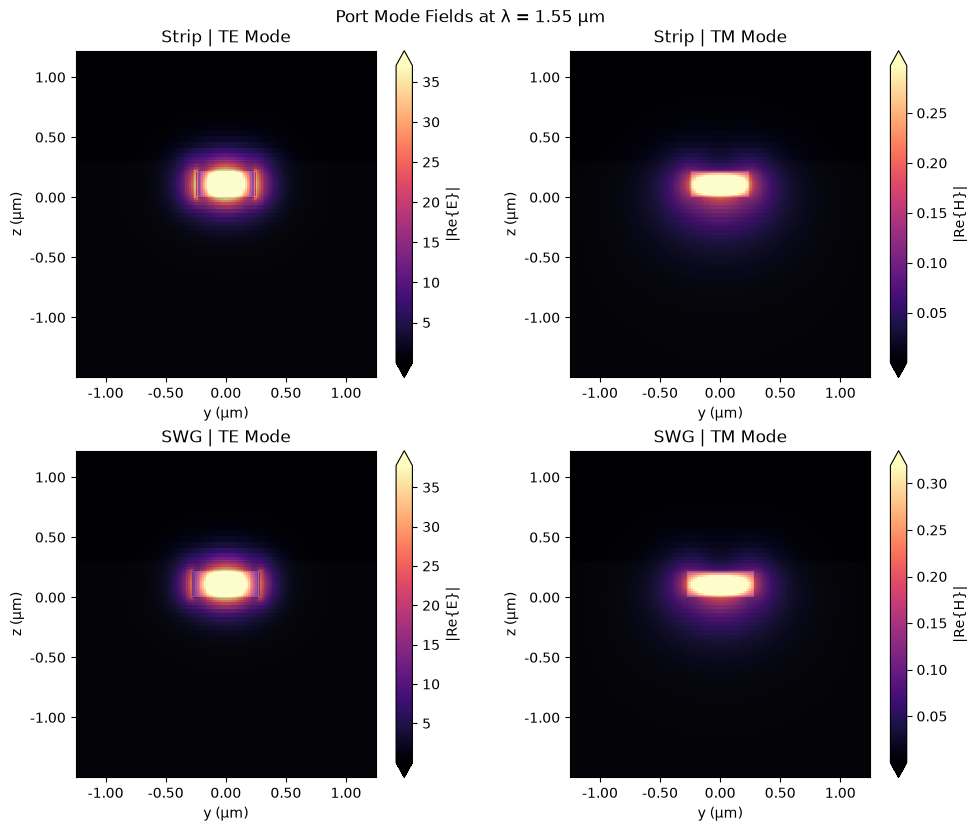

In [5]:
# Create a 2×2 figure layout for two modes (m=0,1) of both ports
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

mode_solver_strip.plot_field("E", mode_index=0, f=f0, ax=axes[0, 0])
mode_solver_strip.plot_field("H", mode_index=1, f=f0, ax=axes[0, 1])
mode_solver_swg.plot_field("E", mode_index=0, f=f0, ax=axes[1, 0])
mode_solver_swg.plot_field("H", mode_index=1, f=f0, ax=axes[1, 1])
axes[0, 0].set_title("Strip | TE Mode")
axes[0, 1].set_title("Strip | TM Mode")
axes[1, 0].set_title("SWG | TE Mode")
axes[1, 1].set_title("SWG | TM Mode")
# Add a shared figure title
fig.suptitle("Port Mode Fields at λ = 1.55 µm", y=1.02)
plt.show()

## Creating PBS

We define a **parametric component** that constructs the SWG-assisted asymmetric coupler used as a polarizing beam splitter:

- The **SWG region** is generated by repeating a unit cell with period $\Lambda$ and duty cycle $f$, producing a coupling length $L_c = N\Lambda$.  
- The **strip waveguide** is routed to run parallel through the coupling region and then transitions via an **S-bend** to separate the outputs.  
- **Ports** are detected and added using the provided `PortSpec`s, allowing us to excite and monitor TE/TM modes consistently across runs.  
- A **Tidy3D model** is attached for subsequent FDTD simulations using the same geometric object.


In [6]:
# Define a parametric component for the SWG-assisted PBS
@pf.parametric_component
def create_pbs(
    *,
    spec_strip=port_spec_strip,
    spec_swg=port_spec_swg,
    w_corrugation=0.130,
    gap=0.200,
    swg_period=0.240,
    swg_duty_cycle=0.5,
    n_periods=30,
    s_bend_length=6,
    s_bend_offset=2,
):
    # Resolve string-based specs from the default technology if needed
    if isinstance(spec_strip, str):
        spec_strip = pf.config.default_technology.ports[spec_strip]
    if isinstance(spec_swg, str):
        spec_swg = pf.config.default_technology.ports[spec_swg]

    # Extract effective silicon widths from the provided PortSpecs
    w_strip, _ = spec_strip.path_profile_for("Si")
    w_swg, _ = spec_swg.path_profile_for("Si")

    # Compute total coupling length from SWG period and number of periods
    coupling_length = n_periods * swg_period

    # Create one SWG unit cell component consisting of ridge + groove
    unit_cell = pf.Component("SWG Period")

    # Build the ridge and groove rectangles for one period
    ridge_length = swg_duty_cycle * swg_period
    ridge = pf.Rectangle((0, -w_swg / 2), (ridge_length, w_swg / 2))
    groove = pf.Rectangle(
        (ridge_length, -w_swg / 2), (swg_period, w_swg / 2 - w_corrugation)
    )

    # Add ridge and groove into the unit cell along +x
    unit_cell.add((1, 0), ridge, groove)

    # Create the parent PBS component
    pbs = pf.Component("PBS")

    # Instantiate the SWG array by repeating the unit cell N times
    swg_array = pf.Reference(
        component=unit_cell, columns=n_periods, rows=1, spacing=(swg_period, 0.0)
    )

    # Add a short straight continuation for the SWG waveguide after coupling region
    swg_wg = pf.Rectangle(
        (coupling_length, -w_swg / 2),
        (coupling_length + s_bend_length + 0.1, w_swg / 2),
    )

    # Route the strip waveguide: lead-in, straight through coupler, then S-bend
    strip_wg = (
        pf.Path(origin=(-1.0, gap + (w_swg + w_strip) / 2), width=w_strip)
        .segment(endpoint=(coupling_length + 1.0, 0), relative=True)
        .s_bend(endpoint=(s_bend_length, s_bend_offset), relative=True)
    )

    # Add geometry to the PBS component (placed along +x)
    pbs.add((1, 0), swg_array, strip_wg, swg_wg)

    # Detect and add ports for strip (input) and SWG (output on +x boundary)
    pbs.add_port(pbs.detect_ports([spec_strip]))
    pbs.add_port(pbs.detect_ports([spec_swg], on_boundary="+x"))

    # Attach a Tidy3D model for simulation
    pbs.add_model(
        pf.Tidy3DModel(
            monitors=[
                td.FieldMonitor(
                    name="field",
                    center=(0, 0, 0.11),
                    size=(td.inf, td.inf, 0),
                    freqs=[pf.C_0 / 1.55],
                )
            ],
        )
    )
    return pbs


# Instantiate and view the PBS component with default parameters
pbs = create_pbs()
viewer(pbs)

## Transmission for TM and TE Inputs

We compute $S$-parameters over the wavelength sweep and plot **transmission in dB** as $10\log_{10}|S|^2$:

- The **left panel** shows **TM input** with **cross** and **thru** responses, including a small inset emphasizing the cross band.  
- The **right panel** shows **TE input** with **cross** and **thru** responses.  


In [6]:
s_matrix = pbs.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})

Uploading task 'P0@0…'
Uploading task 'P0@1…'


Starting task 'P0@0': https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9


Progress: 1% |
Starting task 'P0@1': https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb


Progress: 2% /


Progress: 100% 


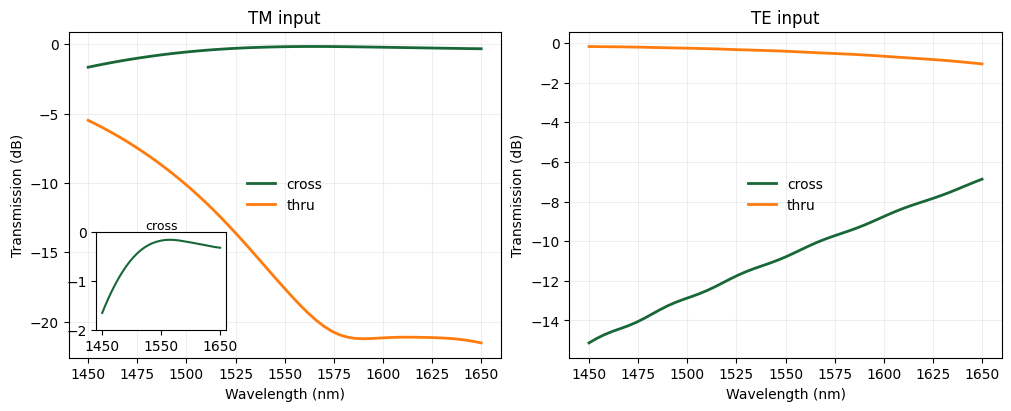

In [7]:
# Define key mapping for S-parameters
k_te_thru = ("P0@0", "P1@0")  # TE input → through
k_te_cross = ("P0@0", "P2@0")  # TE input → cross
k_tm_thru = ("P0@1", "P1@1")  # TM input → through
k_tm_cross = ("P0@1", "P2@1")  # TM input → cross


# Helper to convert complex S-parameter to transmission in dB
def s_to_db(s):
    """
    Return 10*log10(|S|^2) with small floor for numerical stability.
    """
    return 10.0 * np.log10(np.abs(s) ** 2 + 1e-18)


# Extract wavelength axis in nm
wl_nm = wavelengths * 1e3

# Create side-by-side plots for TM input and TE input
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# TM input: plot cross and thru
ax_tm = axes[0]
ax_tm.plot(wl_nm, s_to_db(s_matrix[k_tm_cross]), label="cross", linewidth=2)
ax_tm.plot(wl_nm, s_to_db(s_matrix[k_tm_thru]), label="thru", linewidth=2)
ax_tm.set_xlabel("Wavelength (nm)")
ax_tm.set_ylabel("Transmission (dB)")
ax_tm.set_title("TM input")
ax_tm.legend(loc="center", frameon=False)

# Optional inset for TM cross near 1450–1650 nm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(ax_tm, width="30%", height="30%", loc="lower left", borderpad=2)
axins.plot(wl_nm, s_to_db(s_matrix[k_tm_cross]), linewidth=1.5)
axins.set_xticks([1450, 1550, 1650])
axins.set_yticks([-2, -1, 0])
axins.set_title("cross", fontsize=9, pad=2)

# TE input: plot cross and thru
ax_te = axes[1]
ax_te.plot(wl_nm, s_to_db(s_matrix[k_te_cross]), label="cross", linewidth=2)
ax_te.plot(wl_nm, s_to_db(s_matrix[k_te_thru]), label="thru", linewidth=2)
ax_te.set_xlabel("Wavelength (nm)")
ax_te.set_ylabel("Transmission (dB)")
ax_te.set_title("TE input")
ax_te.legend(loc="center", frameon=False)

# Add an overall style tweak
for ax in axes.ravel():
    ax.grid(True, alpha=0.2)

Finally, we visualize the simulated field distributions of the polarizing beam splitter.

Progress: 100% 


07:26:36 -03 Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=534953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=801659;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9\taskId]8;;\]8;id=534953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9\=]8;;\]8;id=290737;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9\fdve]8;;\]8;id=534953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9\-c4831c49-269]8;;\
             ]8;id=534953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c4831c49-269a-4853-abec-7ee296c32bf9\a-4853-abec-7ee296c32bf9']8;;\.

             Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=138137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=563163;https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb\taskId]8;;\]8;id=138137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb\=]8;;\]8;id=621512;https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb\fdve]8;;\]8;id=138137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb\-07acd648-a70]8;;\
             ]8;id=138137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-07acd648-a70d-4c55-9bcc-eeccde5928eb\d-4c55-9bcc-eeccde5928eb']8;;\.

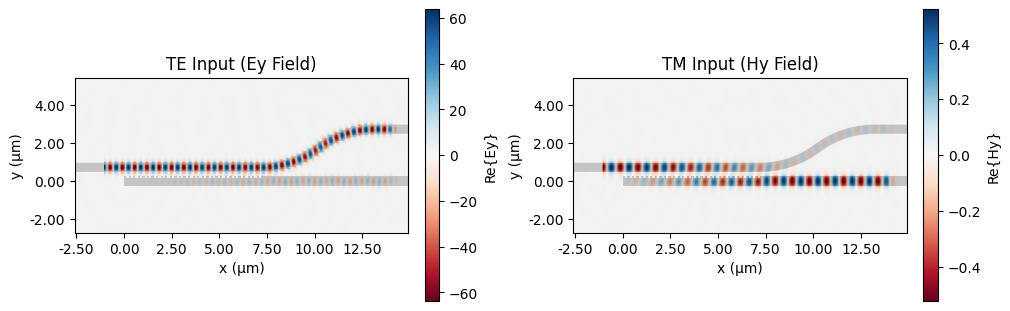

In [8]:
# Retrieve simulation field data for PBS model
sim_data_pbs = pbs.active_model.batch_data(pbs, freqs, inputs=["P0"])

# Create a 1×2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)

# Plot Ey field for TE input (P0@0)
ax0 = sim_data_pbs["P0@0"].plot_field("field", "Ey", ax=axes[0], robust=False)
axes[0].set_title("TE Input (Ey Field)")

# Plot Hy field for TM input (P0@1)
ax1 = sim_data_pbs["P0@1"].plot_field("field", "Hy", ax=axes[1], robust=False)
axes[1].set_title("TM Input (Hy Field)")
plt.show()

### Using FDTDx

S matrix simulation

In [7]:
import jax
jax.devices()

[CudaDevice(id=0)]

## Reproducing the PBS S-matrix and field plot with fdtdx

This section reproduces the Tidy3D results above (cells `98a31514`/`6e472463`/`e4b084e7`) using
`fdtdx` (JAX, GPU) instead, per [`fdtdx.calculate_sparam`](https://fdtdx.readthedocs.io/en/latest/api/fdtdx.calculate_sparam.html).
It is self-contained (re-imports/rebuilds `pbs` locally) so it can run on this kernel without
depending on the Tidy3D cells above — **do not re-run the Tidy3D S-matrix cells**; their outputs
are already baked in and are compared by eye against the plots produced here.

**Geometry/material/port fidelity.** Nothing here is approximated relative to the PhotonForge
definitions above:
- Si geometry comes from `pbs.build_mask((1, 0), heal=True)` (the same merged mask PhotonForge
  would export), not a hand-drawn approximation.
- The silicon index is evaluated from the *same* dispersive medium Tidy3D uses
  (`cSi_Li1993_293K`, found on the `(1, 0)` extrusion spec) at each sweep wavelength.
- Ports use `mode_index=0`/`1` with `filter_pol=None`, **not** fdtdx's `te`/`tm` polarization
  classifier. `fdtdx.core.physics.modes.compute_mode` calls Tidy3D's own `compute_modes`
  internally — the same backend PhotonForge's ports use — and with `filter_pol=None`, modes are
  just sorted by decreasing `real(neff)`, exactly the convention `port_spec_strip`/`port_spec_swg`
  already rely on (mode 0 = TE, mode 1 = TM, as labeled in cell `2742a901` above). Port
  width/height are taken directly from `port_spec_strip.width`/`.limits` (`2.5 µm` / `2.72 µm`),
  not approximated.

**A real constraint found while building this, worth recording:** `fdtdx==0.6.2`'s
`calculate_sparam`/`calculate_sparams` always execute in checkpointed mode internally
(`fdtdx/fdtd/fdtd.py`: `checkpointed_fdtd`'s `kind="lax" if config.only_forward is None else
"checkpointed"` — but `SimulationConfig.only_forward` is a computed `bool` that can never be
`None`, so the cheap non-checkpointed path is unreachable through the public API), even for a
plain forward run with no gradients requested. On this machine's RTX 3070 (8 GB), that made the
mesh needed to resolve the SWG corrugation (130 nm) and gap (200 nm) with any confidence
(≤30 nm resolution) run out of memory, and even a coarser 40 nm mesh that *did* fit took ~13
minutes per polarization per wavelength (~22 h for the full 51-point sweep) — with non-physical
(`|S|>1`) results at that coarseness, since 220 nm of Si at 40 nm resolution is only ~5.5 cells
thick. The cells below use the faithful settings (`resolution = 20e-9`, matching the SWG feature
sizes) rather than a coarsened compromise, since the intent is to run the full sweep on
better-equipped hardware (a university GPU cluster) rather than locally. `resolution`,
`pml_layers`, and `max_time` are exposed as constants at the top of the scene-builder cell so they
can be tuned for whatever hardware runs this.

In [ ]:
import jax
import numpy as np
import photonforge as pf
import siepic_forge as siepic
from fdtdx import ExtrudedPolygon, Material

print("jax devices:", jax.devices())

# Self-contained technology/PBS setup (mirrors the cells above; no Tidy3D dependency)
fdtdx_tech = siepic.ebeam(top_oxide_thickness=0.0)
pf.config.default_technology = fdtdx_tech

fdtdx_port_spec_strip = pf.PortSpec(
    description="Multi mode strip",
    width=2.5,
    num_modes=2,
    target_neff=3.5,
    limits=(-1.5, 1.22),
    path_profiles=[(0.48, 0, (1, 0))],
)
fdtdx_port_spec_swg = pf.PortSpec(
    description="Multi mode swg",
    width=2.5,
    num_modes=2,
    target_neff=3.5,
    limits=(-1.5, 1.22),
    path_profiles=[(0.555, 0, (1, 0))],
)


@pf.parametric_component
def create_pbs_fdtdx(
    *,
    spec_strip=fdtdx_port_spec_strip,
    spec_swg=fdtdx_port_spec_swg,
    w_corrugation=0.130,
    gap=0.200,
    swg_period=0.240,
    swg_duty_cycle=0.5,
    n_periods=30,
    s_bend_length=6,
    s_bend_offset=2,
):
    w_strip, _ = spec_strip.path_profile_for("Si")
    w_swg, _ = spec_swg.path_profile_for("Si")
    coupling_length = n_periods * swg_period
    unit_cell = pf.Component("SWG Period")
    ridge_length = swg_duty_cycle * swg_period
    ridge = pf.Rectangle((0, -w_swg / 2), (ridge_length, w_swg / 2))
    groove = pf.Rectangle(
        (ridge_length, -w_swg / 2), (swg_period, w_swg / 2 - w_corrugation)
    )
    unit_cell.add((1, 0), ridge, groove)
    pbs = pf.Component("PBS")
    swg_array = pf.Reference(
        component=unit_cell, columns=n_periods, rows=1, spacing=(swg_period, 0.0)
    )
    swg_wg = pf.Rectangle(
        (coupling_length, -w_swg / 2),
        (coupling_length + s_bend_length + 0.1, w_swg / 2),
    )
    strip_wg = (
        pf.Path(origin=(-1.0, gap + (w_swg + w_strip) / 2), width=w_strip)
        .segment(endpoint=(coupling_length + 1.0, 0), relative=True)
        .s_bend(endpoint=(s_bend_length, s_bend_offset), relative=True)
    )
    pbs.add((1, 0), swg_array, strip_wg, swg_wg)
    pbs.add_port(pbs.detect_ports([spec_strip]))
    pbs.add_port(pbs.detect_ports([spec_swg], on_boundary="+x"))
    return pbs


fdtdx_pbs = create_pbs_fdtdx()


def _fdtdx_si_medium():
    """The same dispersive Si medium (cSi_Li1993_293K) Tidy3D uses, read off the (1, 0) extrusion spec."""
    for spec in fdtdx_tech.extrusion_specs:
        if (1, 0) in list(spec.mask_layers()):
            return spec.medium["optical"]
    raise RuntimeError("Si layer (1, 0) medium not found in technology")


_fdtdx_si_medium_obj = _fdtdx_si_medium()


def n_si(wavelength_um):
    """Refractive index of Si at the given wavelength (um), from the same medium tidy3d uses."""
    n, k = _fdtdx_si_medium_obj.nk_model(pf.C_0 / wavelength_um)
    return float(n)


# Merged Si-layer mask, in absolute PhotonForge (um) coordinates
fdtdx_si_polygons = fdtdx_pbs.build_mask((1, 0), heal=True)
print(f"n_si(1.55um) = {n_si(1.55):.4f}, {len(fdtdx_si_polygons)} merged Si polygons")

In [ ]:
from fdtdx import PortSpec as FdtdxPortSpec

UM = 1e-6

# Domain: pbs.bounds() padded in x/y; z taken directly from port_spec_strip.limits (not re-derived)
_pad_xy = 1.0  # um
(_x_min, _y_min), (_x_max, _y_max) = fdtdx_pbs.bounds()
_z_lo, _z_hi = fdtdx_port_spec_strip.limits  # (-1.5, 1.22) um
FDTDX_X0, FDTDX_Y0, FDTDX_Z0 = _x_min - _pad_xy, _y_min - _pad_xy, _z_lo  # domain corner, um
FDTDX_LX = (_x_max - _x_min) + 2 * _pad_xy
FDTDX_LY = (_y_max - _y_min) + 2 * _pad_xy
FDTDX_LZ = _z_hi - _z_lo
FDTDX_SI_THICKNESS = 0.22  # um, from the (1, 0) extrusion spec range [0, 0.22]
FDTDX_SI_CENTER_Z = 0.11  # um, mid-Si

print(f"domain (um): Lx={FDTDX_LX:.3f} Ly={FDTDX_LY:.3f} Lz={FDTDX_LZ:.3f}")


def fdtdx_polygons_at(wavelength_um):
    """Build fdtdx ExtrudedPolygons (with center offsets) for the Si mask at the given wavelength."""
    n = n_si(wavelength_um)
    polys = []
    for p in fdtdx_si_polygons:
        v = p.vertices
        vmin, vmax = v.min(axis=0), v.max(axis=0)
        cx, cy = (vmin + vmax) / 2
        vertices_m = (v - [cx, cy]) * UM
        ep = ExtrudedPolygon(
            vertices=vertices_m,
            axis=2,
            material_name="Si",
            materials={"Si": Material(permittivity=n**2)},
            partial_real_shape=(None, None, FDTDX_SI_THICKNESS * UM),
        )
        offset_m = (
            (cx - FDTDX_X0) * UM,
            (cy - FDTDX_Y0) * UM,
            (FDTDX_SI_CENTER_Z - FDTDX_Z0) * UM,
        )
        polys.append((ep, offset_m))
    return polys


def _fdtdx_port_offset(center_xy):
    z_center_um = (_z_lo + _z_hi) / 2
    return (
        (center_xy[0] - FDTDX_X0) * UM,
        (center_xy[1] - FDTDX_Y0) * UM,
        (z_center_um - FDTDX_Z0) * UM,
    )


def fdtdx_make_port(center_xy, width_um, mode_index, name):
    """fdtdx PortSpec faithful to the pf.PortSpec window: filter_pol=None (mode 0 = TE, 1 = TM,
    same convention as port_spec_strip/port_spec_swg — see markdown note above)."""
    return FdtdxPortSpec(
        center=_fdtdx_port_offset(center_xy),
        axis=0,
        direction="+",
        width=width_um * UM,
        height=FDTDX_LZ * UM,
        mode_index=mode_index,
        filter_pol=None,
        name=name,
    )


_p0c = fdtdx_pbs.ports["P0"].center
_p1c = fdtdx_pbs.ports["P1"].center
_p2c = fdtdx_pbs.ports["P2"].center

FDTDX_P0_M0 = fdtdx_make_port(_p0c, fdtdx_port_spec_strip.width, 0, "P0_m0")
FDTDX_P0_M1 = fdtdx_make_port(_p0c, fdtdx_port_spec_strip.width, 1, "P0_m1")
FDTDX_P1_M0 = fdtdx_make_port(_p1c, fdtdx_port_spec_strip.width, 0, "P1_m0")
FDTDX_P1_M1 = fdtdx_make_port(_p1c, fdtdx_port_spec_strip.width, 1, "P1_m1")
FDTDX_P2_M0 = fdtdx_make_port(_p2c, fdtdx_port_spec_swg.width, 0, "P2_m0")
FDTDX_P2_M1 = fdtdx_make_port(_p2c, fdtdx_port_spec_swg.width, 1, "P2_m1")

In [ ]:
from fdtdx import setup_sparams_simulation, calculate_sparams

# First-pass mesh/timing settings -- tune these for the hardware actually running this (see
# markdown note above: 20nm did not fit in 8GB VRAM here; these are the faithful values intended
# for a machine with more headroom, not a compromise settled on locally).
FDTDX_RESOLUTION = 20e-9  # m; resolves the 130nm corrugation depth / 200nm gap with several points
FDTDX_PML_LAYERS = 8
FDTDX_MAX_TIME = 3e-12  # s; upper bound, calculate_sparam auto-stops early via EnergyThresholdCondition


def fdtdx_run_wavelength(wavelength_um, show_progress=False):
    """Build the scene at wavelength_um and return the S-parameter dict for both TE (m0) and TM
    (m1) inputs, keyed (detector_name, input_port_name) as in fdtdx.calculate_sparams."""
    objects, arrays, config = setup_sparams_simulation(
        polygons=fdtdx_polygons_at(wavelength_um),
        input_ports=[FDTDX_P0_M0, FDTDX_P0_M1],
        output_ports=[FDTDX_P1_M0, FDTDX_P1_M1, FDTDX_P2_M0, FDTDX_P2_M1],
        wavelength=wavelength_um * UM,
        resolution=FDTDX_RESOLUTION,
        max_time=FDTDX_MAX_TIME,
        domain_size=(FDTDX_LX * UM, FDTDX_LY * UM, FDTDX_LZ * UM),
        pml_layers=FDTDX_PML_LAYERS,
    )
    sparams, _ = calculate_sparams(
        objects,
        arrays,
        config,
        input_port_names=["P0_m0", "P0_m1"],
        show_progress=show_progress,
    )
    return sparams

**Smoke test before the full sweep.** Run a single wavelength first to catch integration mistakes
cheaply and to get a real per-point timing estimate for the hardware this runs on, before
committing to the full 51-point x 2-polarization (102-run) sweep below. Sanity check: `|S| <= 1`
for every entry (energy conservation) and the field plot (further below) should show a mode
confined to the waveguide core, not radiating into the cladding.

In [ ]:
import time

_t0 = time.time()
_smoke_sparams = fdtdx_run_wavelength(1.55, show_progress=True)
print(f"smoke test done in {time.time() - _t0:.1f}s")
for k, v in _smoke_sparams.items():
    print(f"  {k}: |S|={abs(v):.4f}  ({v:.4f})")

**Full sweep.** Loops 51 wavelengths over 1.45-1.65 µm (matching the Tidy3D sweep's `wavelengths`
array), at 2 runs (TE, TM) per wavelength = 102 FDTD runs total. This is the expensive cell (see
the runtime finding in the markdown note above) — intended to run on hardware with more VRAM than
this machine's RTX 3070.

In [ ]:
fdtdx_wavelengths = np.linspace(1.45, 1.65, 51)  # matches `wavelengths` in the Tidy3D cells above

fdtdx_te_thru = np.zeros(len(fdtdx_wavelengths), dtype=complex)
fdtdx_te_cross = np.zeros(len(fdtdx_wavelengths), dtype=complex)
fdtdx_tm_thru = np.zeros(len(fdtdx_wavelengths), dtype=complex)
fdtdx_tm_cross = np.zeros(len(fdtdx_wavelengths), dtype=complex)

_t_sweep0 = time.time()
for _i, _wl in enumerate(fdtdx_wavelengths):
    _sp = fdtdx_run_wavelength(float(_wl), show_progress=False)
    fdtdx_te_thru[_i] = _sp[("P1_m0", "P0_m0")]
    fdtdx_te_cross[_i] = _sp[("P2_m0", "P0_m0")]
    fdtdx_tm_thru[_i] = _sp[("P1_m1", "P0_m1")]
    fdtdx_tm_cross[_i] = _sp[("P2_m1", "P0_m1")]
    print(f"[{_i + 1}/{len(fdtdx_wavelengths)}] wl={_wl:.3f}um  elapsed={time.time() - _t_sweep0:.0f}s")

print(f"sweep done in {time.time() - _t_sweep0:.0f}s")

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def s_to_db(s):
    """Return 10*log10(|S|^2) with small floor for numerical stability (same as cell 6e472463)."""
    return 10.0 * np.log10(np.abs(s) ** 2 + 1e-18)


fdtdx_wl_nm = fdtdx_wavelengths * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax_tm = axes[0]
ax_tm.plot(fdtdx_wl_nm, s_to_db(fdtdx_tm_cross), label="cross", linewidth=2)
ax_tm.plot(fdtdx_wl_nm, s_to_db(fdtdx_tm_thru), label="thru", linewidth=2)
ax_tm.set_xlabel("Wavelength (nm)")
ax_tm.set_ylabel("Transmission (dB)")
ax_tm.set_title("TM input (fdtdx)")
ax_tm.legend(loc="center", frameon=False)

axins = inset_axes(ax_tm, width="30%", height="30%", loc="lower left", borderpad=2)
axins.plot(fdtdx_wl_nm, s_to_db(fdtdx_tm_cross), linewidth=1.5)
axins.set_xticks([1450, 1550, 1650])
axins.set_title("cross", fontsize=9, pad=2)

ax_te = axes[1]
ax_te.plot(fdtdx_wl_nm, s_to_db(fdtdx_te_cross), label="cross", linewidth=2)
ax_te.plot(fdtdx_wl_nm, s_to_db(fdtdx_te_thru), label="thru", linewidth=2)
ax_te.set_xlabel("Wavelength (nm)")
ax_te.set_ylabel("Transmission (dB)")
ax_te.set_title("TE input (fdtdx)")
ax_te.legend(loc="center", frameon=False)

for ax in axes.ravel():
    ax.grid(True, alpha=0.2)

fig.suptitle("fdtdx S-matrix -- compare by eye against cell 6e472463 above", y=1.05)
plt.show()

## Field plot (fdtdx)

`setup_sparams_simulation` only builds mode sources/detectors, not a frequency-domain field
monitor, so this hand-rolls the same scene-construction pattern (`fdtdx.setup_sparams_simulation`'s
own implementation, mirrored here) with one addition: a `PhasorDetector` recording a thin z-slice
at `z=0.11 µm` (mid-Si) across the full x/y domain at `λ=1.55 µm`, equivalent to the Tidy3D
`FieldMonitor` used in `create_pbs`/cell `e4b084e7`.

In [ ]:
from fdtdx import (
    SimulationConfig,
    SimulationVolume,
    BoundaryConfig,
    boundary_objects_from_config,
    PhasorDetector,
    WaveCharacter,
    GaussianPulseProfile,
    extend_material_to_pml,
    place_objects,
    calculate_sparam,
)
from fdtdx.objects.sources.mode import ModePlaneSource
from fdtdx.objects.detectors.mode import ModeOverlapDetector

FDTDX_FIELD_WAVELENGTH_UM = 1.55


def _make_port_shape(axis, resolution, width, height):
    """Same as fdtdx.utils.sparams._make_port_shape: one-voxel thickness along the propagation axis."""
    transverse = [i for i in range(3) if i != axis]
    shape = [resolution, resolution, resolution]
    shape[transverse[0]] = width
    shape[transverse[1]] = height
    return tuple(shape)


def fdtdx_build_field_scene(input_port):
    """Mirrors fdtdx.setup_sparams_simulation's internal scene construction (its source is the
    reference: source + input-normalization detector for the one active input port), with one
    addition: a PhasorDetector z-slice at mid-Si for the field plot. No output S-param detectors
    here -- this cell is only for the field pattern, not S-parameters (see the sweep above)."""
    pml_thickness = FDTDX_PML_LAYERS * FDTDX_RESOLUTION
    total_size = (
        FDTDX_LX * UM + 2 * pml_thickness,
        FDTDX_LY * UM + 2 * pml_thickness,
        FDTDX_LZ * UM + 2 * pml_thickness,
    )
    config = SimulationConfig(time=FDTDX_MAX_TIME, resolution=FDTDX_RESOLUTION)
    background = SimulationVolume(partial_real_shape=total_size, material=Material(), name="Background")
    object_list = [background]
    constraints = []

    bcfg = BoundaryConfig(
        thickness_grid_minx=FDTDX_PML_LAYERS,
        thickness_grid_maxx=FDTDX_PML_LAYERS,
        thickness_grid_miny=FDTDX_PML_LAYERS,
        thickness_grid_maxy=FDTDX_PML_LAYERS,
        thickness_grid_minz=FDTDX_PML_LAYERS,
        thickness_grid_maxz=FDTDX_PML_LAYERS,
    )
    bdict, bcons = boundary_objects_from_config(bcfg, background)
    object_list.extend(bdict.values())
    constraints.extend(bcons)

    def _center_at(obj, offset):
        return obj.place_relative_to(
            background,
            axes=(0, 1, 2),
            own_positions=(0.0, 0.0, 0.0),
            other_positions=(-1.0, -1.0, -1.0),
            margins=(offset[0] + pml_thickness, offset[1] + pml_thickness, offset[2] + pml_thickness),
        )

    for poly, offset in fdtdx_polygons_at(FDTDX_FIELD_WAVELENGTH_UM):
        object_list.append(poly)
        constraints.append(_center_at(poly, offset))

    center_wave = WaveCharacter(wavelength=FDTDX_FIELD_WAVELENGTH_UM * UM)
    profile = GaussianPulseProfile(
        center_wave=center_wave,
        spectral_width=WaveCharacter(wavelength=FDTDX_FIELD_WAVELENGTH_UM * UM * 10),
    )
    port_shape = _make_port_shape(input_port.axis, FDTDX_RESOLUTION, input_port.width, input_port.height)

    source = ModePlaneSource(
        mode_index=input_port.mode_index,
        filter_pol=input_port.filter_pol,
        direction=input_port.direction,
        temporal_profile=profile,
        wave_character=center_wave,
        partial_real_shape=port_shape,
        name=input_port.name,
    )
    object_list.append(source)
    constraints.append(_center_at(source, input_port.center))

    # calculate_sparam requires a "<name>_input_normalization" ModeOverlapDetector next to the source
    input_norm_det = ModeOverlapDetector(
        mode_index=input_port.mode_index,
        filter_pol=input_port.filter_pol,
        direction=input_port.direction,
        wave_characters=(center_wave,),
        partial_real_shape=port_shape,
        name=f"{input_port.name}_input_normalization",
    )
    object_list.append(input_norm_det)
    margins = [0, 0, 0]
    margins[input_port.axis] = 1 if input_port.direction == "+" else -1
    constraints.append(input_norm_det.same_position(source, grid_margins=tuple(margins)))

    field_det = PhasorDetector(
        wave_characters=[center_wave],
        partial_real_shape=(FDTDX_LX * UM, FDTDX_LY * UM, FDTDX_RESOLUTION),
        name="field_slice",
    )
    object_list.append(field_det)
    constraints.append(
        _center_at(field_det, (FDTDX_LX * UM / 2, FDTDX_LY * UM / 2, FDTDX_SI_CENTER_Z - FDTDX_Z0))
    )

    objects, arrays, _, config, _ = place_objects(
        object_list=object_list, config=config, constraints=constraints, key=jax.random.PRNGKey(0)
    )
    arrays = extend_material_to_pml(objects=objects, arrays=arrays)
    return objects, arrays, config


_, _field_states_te = calculate_sparam(
    *fdtdx_build_field_scene(FDTDX_P0_M0), input_port_name="P0_m0", show_progress=True
)
_, _field_states_tm = calculate_sparam(
    *fdtdx_build_field_scene(FDTDX_P0_M1), input_port_name="P0_m1", show_progress=True
)
print("field runs done:", list(_field_states_te.keys()))